# Sample and visualize 2024 outages

This notebook selects a reproducible random date in 2024, exports 20 outage records as a LaTeX table, and visualizes the following seven days. Only dates with at least 20 records are eligible.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("processed-actual-outages.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 43

date_columns = ["OutDatetime", "MinTimeStamp", "MaxTimeStamp"]
outages = (
    pd.read_csv(DATA_PATH, parse_dates=date_columns)
    .sort_values("MinTimeStamp", kind="stable")
    .reset_index(drop=True)
)

outages_2024 = outages.loc[outages["MinTimeStamp"].dt.year.eq(2024)].copy()
daily_counts = outages_2024.groupby(outages_2024["MinTimeStamp"].dt.normalize()).size()
eligible_dates = daily_counts.loc[daily_counts.ge(20)].index.to_numpy()

rng = np.random.default_rng(RANDOM_SEED)
random_date = pd.Timestamp(rng.choice(eligible_dates))
on_random_date = outages_2024["MinTimeStamp"].dt.normalize().eq(random_date)
sample = outages_2024.loc[on_random_date].head(20).copy()

print(f"Selected date: {random_date:%Y-%m-%d}")
print(f"Rows available on selected date: {daily_counts.loc[random_date]}")
sample

Selected date: 2024-06-03
Rows available on selected date: 23


,PTID,Name,OutDatetime,MinTimeStamp,MaxTimeStamp,Voltage,FirstBus,SecondBus,OutageType
67423,25539,PORTJEFF-HOLBROOK_138_862,2024-06-03 01:17:00,2024-06-03 00:22:00,2024-06-05 18:37:00,138,PORTJEFF,HOLBROOK,Planned
67424,326888,CRICKVLY-PLSNTVLY_345_F84,2024-06-03 01:26:00,2024-06-03 00:32:00,2024-06-04 21:17:00,345,CRICKVLY,PLSNTVLY,Planned
67425,101015113,ALANBURG-BECK_____220_Q26M,2024-06-03 06:16:00,2024-06-03 05:17:00,2024-06-11 12:07:00,220,ALANBURG,BECK____,Auto
67426,25051,CHASLAKE-PORTER___230_11,2024-06-03 06:38:00,2024-06-03 05:42:00,2024-06-11 12:07:00,230,CHASLAKE,PORTER__,Planned
67427,100000186,HIGHG_TP-S ALBN J_115_K42-2,2024-06-03 07:00:00,2024-06-03 06:42:00,2024-06-03 16:02:00,115,HIGHG_TP,S ALBN J,Auto
67428,101017626,HIGHGATE-HIGHG_TP_115_K42HG,2024-06-03 07:00:00,2024-06-03 06:42:00,2024-06-04 10:12:00,115,HIGHGATE,HIGHG_TP,Auto
67429,101017950,HIGHG_TP-CONVERTR_115_K42-3,2024-06-03 07:00:00,2024-06-03 06:42:00,2024-06-03 16:02:00,115,HIGHG_TP,CONVERTR,Auto
67430,25198,VOLNEY__-CLAY_____345_6,2024-06-03 08:46:00,2024-06-03 07:52:00,2024-06-03 09:42:00,345,VOLNEY__,CLAY____,Planned
67431,25087,LOCKPORT-HINMAN___115_100,2024-06-03 10:09:00,2024-06-03 09:12:00,2024-06-03 14:47:00,115,LOCKPORT,HINMAN__,Planned
67432,25867,PATROON_-PATRTAP__115_15,2024-06-03 10:44:00,2024-06-03 09:47:00,2024-06-03 12:47:00,115,PATROON_,PATRTAP_,Planned


In [6]:
table_columns = {
    "OutDatetime": "Outage time",
    "PTID": "PTID",
    "Name": "Line",
    "Voltage": "kV",
    "OutageType": "Type",
    "MinTimeStamp": "First report",
    "MaxTimeStamp": "Last report",
}
latex_table = sample[list(table_columns)].rename(columns=table_columns)
latex_table.insert(0, "No.", range(1, len(latex_table) + 1))

TEX_PATH = OUTPUT_DIR / f"sample_outages_{random_date:%Y-%m-%d}.tex"
latex_table.to_latex(
    TEX_PATH,
    index=False,
    escape=True,
    caption=(f"First 20 outages on {random_date:%Y-%m-%d}, " "sorted by MinTimeStamp."),
    label="tab:sample-outages-2024",
    position="htbp",
)

print(f"Saved LaTeX table to {TEX_PATH.resolve()}")

Saved LaTeX table to /home/aj/phd/nyiso-data/src/output/sample_outages_2024-06-03.tex


Plotted 23 outages; saved figure to /home/aj/phd/nyiso-data/src/output/outage_day_2024-06-03.pdf


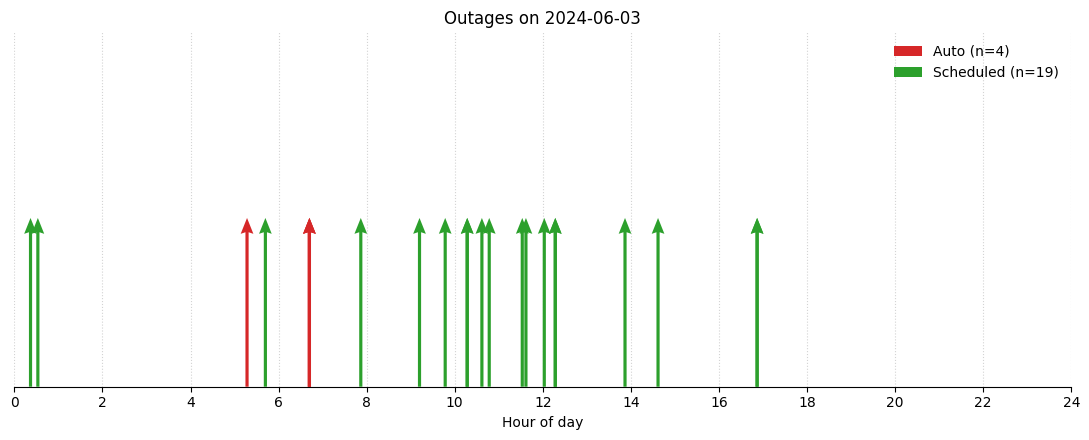

In [12]:
day_end = random_date + pd.Timedelta(days=1)
day = outages.loc[
    outages["MinTimeStamp"].between(random_date, day_end, inclusive="left")
].copy()
day["HourOfDay"] = (day["MinTimeStamp"] - random_date).dt.total_seconds().div(60 * 60)

styles = {
    "Auto": {
        "color": "#d62728",
        "label": "Auto",
    },
    "Planned": {
        "color": "#2ca02c",
        "label": "Scheduled",
    },
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for outage_type, style in styles.items():
    events = day.loc[day["OutageType"].eq(outage_type)]
    ax.quiver(
        events["HourOfDay"],
        np.zeros(len(events)),
        np.zeros(len(events)),
        np.ones(len(events)),
        color=style["color"],
        angles="xy",
        scale_units="xy",
        scale=3,
        width=0.003,
        headwidth=4,
        headlength=5,
        headaxislength=4.5,
        pivot="tail",
        label=f'{style["label"]} (n={len(events)})',
        zorder=3,
    )

ax.set(
    xlim=(0, 24),
    xticks=np.arange(0, 25, 2),
    xlabel="Hour of day",
    yticks=[],
    ylim=(0, 0.7),
    title=f"Outages on {random_date:%Y-%m-%d}",
)
ax.grid(axis="x", linestyle=":", alpha=0.55)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()

PDF_PATH = OUTPUT_DIR / f"outage_day_{random_date:%Y-%m-%d}.pdf"
fig.savefig(PDF_PATH, bbox_inches="tight")
print(f"Plotted {len(day)} outages; saved figure to {PDF_PATH.resolve()}")
plt.show()